In [1]:
# ─────────────────────────────────────────
# HR Employee Attrition Analysis
# Author: Pruthviraj Kadam
# Tools: Python, Pandas, Matplotlib, Seaborn
# Dataset: 1,470 employees | 29 columns
# ─────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('hr_employee_data.csv')

# Always do this first — understand your data before touching it
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nAttrition counts:\n", df['Attrition'].value_counts())

Shape: (1470, 29)

Column names:
 ['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Department', 'JobRole', 'EducationField', 'Education', 'BusinessTravel', 'DistanceFromHome', 'MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel', 'OverTime', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'JobInvolvement', 'JobLevel', 'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']

Data types:
 EmployeeID                   int64
Age                          int64
Gender                      object
MaritalStatus               object
Department                  object
JobRole                     object
EducationField              object
Education                    int64
BusinessTravel              object
DistanceFromHome             int64
MonthlyIncome                int64
PercentSalaryHike            int64
Sto

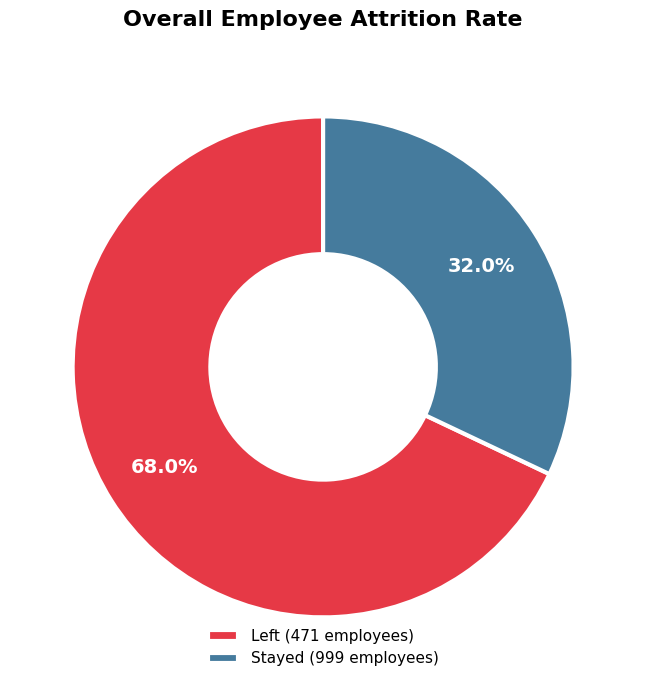

Chart 1 saved


In [2]:
# ── CHART 1: Overall Attrition Donut ──────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

attrition_counts = df['Attrition'].value_counts()
colors = ['#E63946', '#457B9D']  # Red = left, Blue = stayed

wedges, texts, autotexts = ax.pie(
    attrition_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 3}
)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Add legend
ax.legend(
    [f"Left ({attrition_counts['Yes']} employees)",
     f"Stayed ({attrition_counts['No']} employees)"],
    loc='lower center',
    fontsize=11,
    frameon=False
)

ax.set_title('Overall Employee Attrition Rate', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart1_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

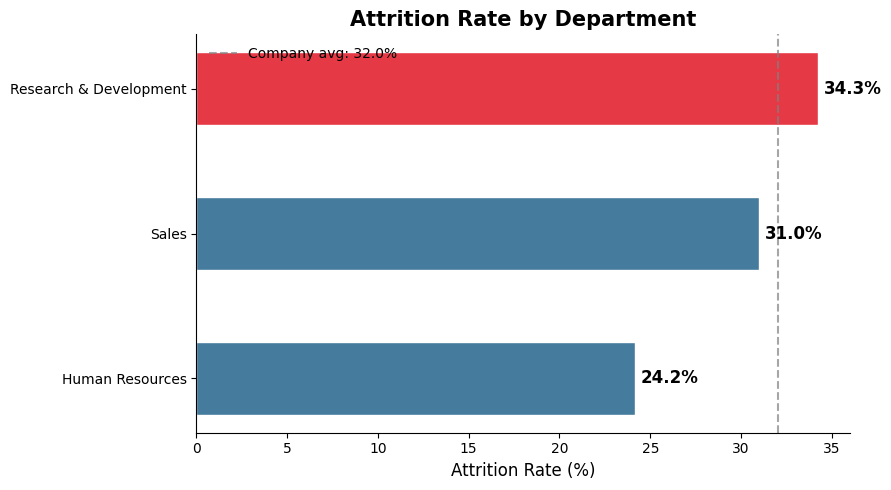

Chart 2 saved


In [3]:
# ── CHART 2: Attrition Rate by Department ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Calculate attrition rate per department
dept_attrition = df.groupby('Department').apply(
    lambda x: (x['Attrition'] == 'Yes').mean() * 100
).sort_values(ascending=True)  # ascending=True so highest is at top

colors = ['#E63946' if v == dept_attrition.max() 
          else '#457B9D' for v in dept_attrition.values]

bars = ax.barh(dept_attrition.index, dept_attrition.values,
               color=colors, height=0.5, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, dept_attrition.values):
    ax.text(val + 0.3, 
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', fontsize=12, fontweight='bold')

# Add average line
avg = (df['Attrition'] == 'Yes').mean() * 100
ax.axvline(avg, color='gray', linestyle='--', 
           alpha=0.7, label=f'Company avg: {avg:.1f}%')

ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_title('Attrition Rate by Department', 
             fontsize=15, fontweight='bold')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_dept_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

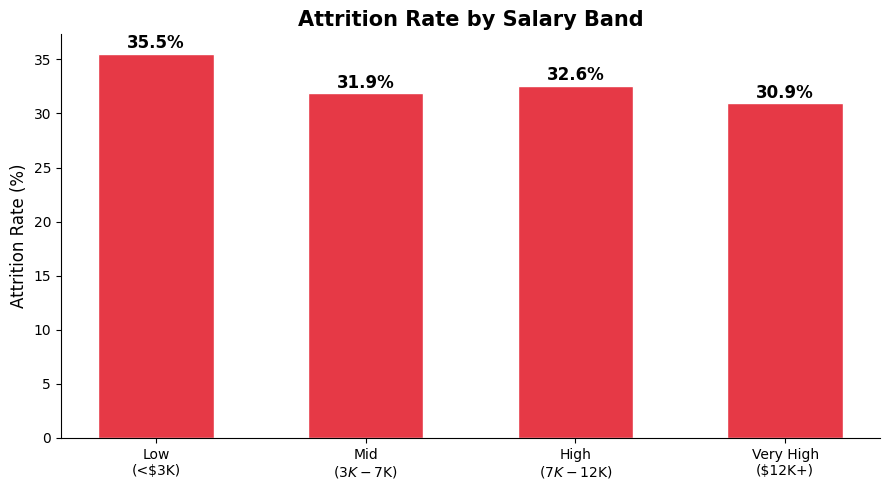

Chart 3 saved


In [4]:
# ── CHART 3: Salary Band vs Attrition ─────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Create salary bands — same logic as SQL CASE WHEN
df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 7000, 12000, float('inf')],
    labels=['Low\n(<$3K)', 'Mid\n($3K-$7K)', 
            'High\n($7K-$12K)', 'Very High\n($12K+)']
)

sal_attrition = df.groupby('SalaryBand', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

colors = ['#E63946' if v > 25 else '#457B9D' 
          for v in sal_attrition.values]

bars = ax.bar(sal_attrition.index, sal_attrition.values,
              color=colors, width=0.55, edgecolor='white')

for bar, val in zip(bars, sal_attrition.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_title('Attrition Rate by Salary Band', 
             fontsize=15, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_salary_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

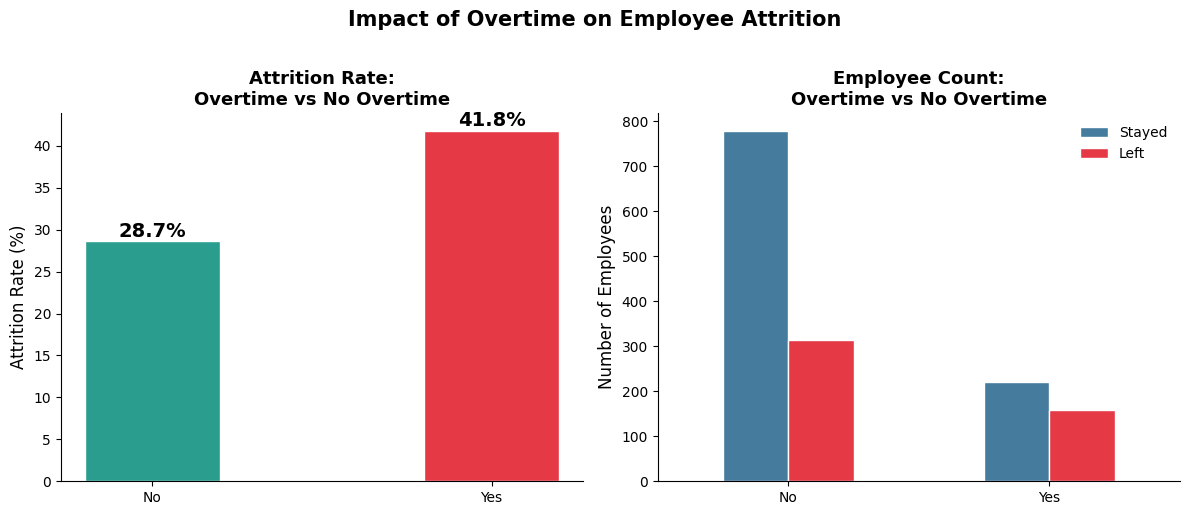

Chart 4 saved


In [5]:
# ── CHART 4: Overtime Impact ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: Attrition rate
ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

bars = axes[0].bar(ot_rate.index, ot_rate.values,
                   color=['#2A9D8F', '#E63946'],
                   width=0.4, edgecolor='white')

for bar, val in zip(bars, ot_rate.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center', fontsize=14, fontweight='bold')

axes[0].set_ylabel('Attrition Rate (%)', fontsize=12)
axes[0].set_title('Attrition Rate:\nOvertime vs No Overtime',
                  fontsize=13, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right chart: Employee count breakdown
ot_counts = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot_counts.plot(kind='bar', ax=axes[1],
               color=['#457B9D', '#E63946'],
               edgecolor='white', width=0.5)

axes[1].set_title('Employee Count:\nOvertime vs No Overtime',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Employees', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Stayed', 'Left'], frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Impact of Overtime on Employee Attrition',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_overtime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

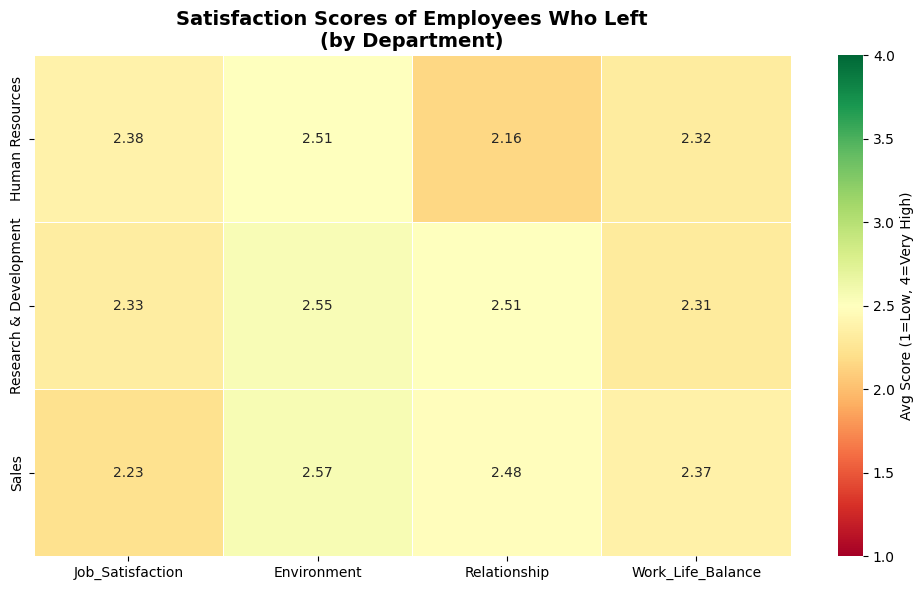

Chart 5 saved


In [6]:
# ── CHART 5: Satisfaction Heatmap ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Build pivot — avg satisfaction for attrited employees by dept
pivot = df[df['Attrition'] == 'Yes'].groupby('Department').agg(
    Job_Satisfaction=('JobSatisfaction', 'mean'),
    Environment=('EnvironmentSatisfaction', 'mean'),
    Relationship=('RelationshipSatisfaction', 'mean'),
    Work_Life_Balance=('WorkLifeBalance', 'mean')
).round(2)

sns.heatmap(
    pivot,
    annot=True,           # Show numbers inside cells
    fmt='.2f',            # 2 decimal places
    cmap='RdYlGn',        # Red = low, Yellow = medium, Green = high
    vmin=1, vmax=4,       # Fix scale to match our 1-4 rating system
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Avg Score (1=Low, 4=Very High)'}
)

ax.set_title('Satisfaction Scores of Employees Who Left\n(by Department)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('chart5_satisfaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

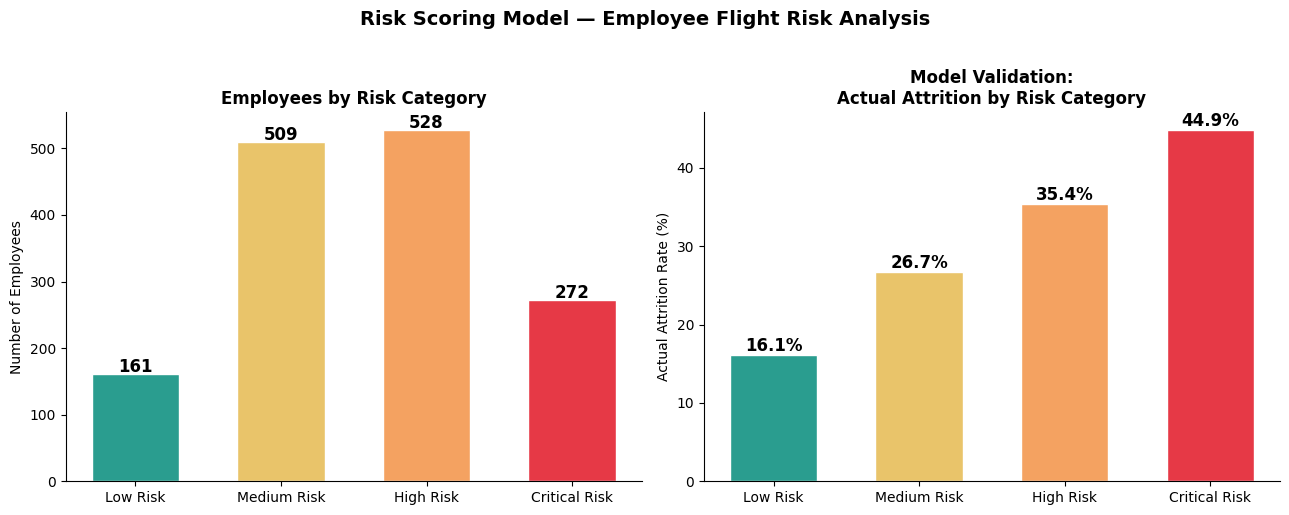

Chart 6 saved


In [7]:
# ── CHART 6: Risk Score Distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calculate risk score
df['RiskScore'] = (
    ((df['OverTime'] == 'Yes').astype(int) * 2) +
    ((df['JobSatisfaction'] <= 2).astype(int) * 2) +
    ((df['WorkLifeBalance'] <= 2).astype(int) * 2) +
    ((df['YearsAtCompany'] <= 2).astype(int) * 1) +
    ((df['MonthlyIncome'] < 3000).astype(int) * 1) +
    ((df['YearsSinceLastPromotion'] >= 3).astype(int) * 1) +
    ((df['NumCompaniesWorked'] > 5).astype(int) * 1)
)

df['RiskCategory'] = pd.cut(
    df['RiskScore'],
    bins=[-1, 1, 3, 5, 10],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

# Left: Count by risk category
risk_counts = df['RiskCategory'].value_counts().sort_index()
colors_r = ['#2A9D8F', '#E9C46A', '#F4A261', '#E63946']

bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=colors_r, edgecolor='white', width=0.6)

for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 3,
                 str(val),
                 ha='center', fontsize=12, fontweight='bold')

axes[0].set_ylabel('Number of Employees')
axes[0].set_title('Employees by Risk Category', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Actual attrition rate per risk category — MODEL VALIDATION
risk_val = df.groupby('RiskCategory', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

bars2 = axes[1].bar(risk_val.index, risk_val.values,
                    color=colors_r, edgecolor='white', width=0.6)

for bar, val in zip(bars2, risk_val.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

axes[1].set_ylabel('Actual Attrition Rate (%)')
axes[1].set_title('Model Validation:\nActual Attrition by Risk Category',
                  fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Risk Scoring Model — Employee Flight Risk Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_risk_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

In [8]:
# ── PRINT KEY FINDINGS ────────────────────────────────────
print("\n" + "="*50)
print("  KEY FINDINGS — HR ATTRITION ANALYSIS")
print("="*50)

att_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"\n1. Overall attrition rate: {att_rate:.1f}%")

top_dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).idxmax()
print(f"2. Highest attrition department: {top_dept}")

ot_yes = df[df['OverTime']=='Yes']['Attrition'].eq('Yes').mean()*100
ot_no  = df[df['OverTime']=='No']['Attrition'].eq('Yes').mean()*100
print(f"3. Overtime attrition: {ot_yes:.1f}% vs No overtime: {ot_no:.1f}%")
print(f"   → Overtime employees leave {ot_yes/ot_no:.1f}x more often")

income_left   = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
income_stayed = df[df['Attrition']=='No']['MonthlyIncome'].mean()
print(f"4. Avg income — Left: ${income_left:,.0f} | Stayed: ${income_stayed:,.0f}")
print(f"   → Income gap: ${income_stayed - income_left:,.0f}/month")

critical = df[df['RiskCategory']=='Critical Risk']
print(f"5. Critical risk employees: {len(critical)}")
print(f"   → Actual attrition in this group: "
      f"{(critical['Attrition']=='Yes').mean()*100:.1f}%")

print("\n" + "="*50)
print("All 6 charts saved. Ready for Power BI and GitHub.")
print("="*50)


  KEY FINDINGS — HR ATTRITION ANALYSIS

1. Overall attrition rate: 32.0%
2. Highest attrition department: Research & Development
3. Overtime attrition: 41.8% vs No overtime: 28.7%
   → Overtime employees leave 1.5x more often
4. Avg income — Left: $10,350 | Stayed: $10,546
   → Income gap: $195/month
5. Critical risk employees: 272
   → Actual attrition in this group: 44.9%

All 6 charts saved. Ready for Power BI and GitHub.
